In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import time
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchvision.utils import make_grid
from scipy.signal import savgol_filter

In [86]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec


In [87]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [88]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

In [89]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

In [90]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

In [91]:
# set the device, default to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [92]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [93]:
# Loading hit data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

 36%|███▌      | 358/1000 [00:01<00:01, 345.48it/s]


KeyboardInterrupt: 

In [ ]:
event_train = events_train[:SELECTED_EVENTS][0]

In [ ]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [ ]:
# We keep this as global variable we will reference throughout this notebook
config = {
    'batch_size': 64,
    'n_channels': 1, # for MNIST
    'n_epochs': 80,
    'n_hiddens': 128,
    'n_residual_hiddens': 32,
    'n_residual_layers': 2,
    'embedding_dim': 16, # latent dimension
    'n_embeddings': 128, # codebook entries count
    'beta': 0.5,
    'learning_rate': 1e-3, # 3e-4
    'plot_epochs': 10, # plto every plot_epochs of training
    'dataset': 'MNIST',
    'data_dir': 'data/',
    'save_dir': 'results/',
    }

print(f'Model checkpoints and results will be saved in {config["save_dir"]}')
print(f'Data will be saved in {config["data_dir"]}')

if not os.path.exists(config["save_dir"]):
    os.makedirs(config["save_dir"])

if not os.path.exists(config["data_dir"]):
    os.makedirs(config["data_dir"])

Model checkpoints and results will be saved in results/
Data will be saved in data/


In [ ]:
def save_model_and_results(model, results):
    timestamp = int(time.time())
    save_path = os.path.join(config["save_dir"], f'vqvae_{config["dataset"]}_{timestamp}.pth')
    print(f"Saving checkpoint in: {save_path}")
    torch.save({
        'model': model.state_dict(),
        'results': results,
        'config': config
    }, save_path)

In [ ]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
batch_size = config["batch_size"]
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


In [ ]:
np.unique(next(iter(train_loader)))

array([-1.        , -0.7647059 , -0.7490196 , -0.7411765 , -0.73333335,
       -0.7254902 , -0.7176471 , -0.70980394, -0.7019608 , -0.69411767,
       -0.6862745 , -0.6784314 , -0.67058825, -0.6627451 , -0.654902  ,
       -0.64705884, -0.6392157 , -0.6313726 , -0.62352943, -0.6156863 ,
       -0.6       , -0.5921569 , -0.58431375, -0.5764706 , -0.56078434,
       -0.5529412 , -0.54509807, -0.5372549 , -0.5294118 , -0.5137255 ,
       -0.4980392 , -0.49019605, -0.4823529 , -0.47450978, -0.45098037,
       -0.44313723, -0.4352941 , -0.42745095, -0.41960782, -0.41176468,
       -0.40392154, -0.3960784 , -0.38823527, -0.36470586, -0.35686272,
       -0.3490196 , -0.34117645, -0.3333333 , -0.32549018, -0.3098039 ,
       -0.30196077, -0.2862745 , -0.27058822, -0.26274508, -0.24705881,
       -0.23921567, -0.23137254, -0.2235294 , -0.20784312, -0.19999999,
       -0.18431371, -0.17647058, -0.1607843 , -0.14509803, -0.11372548,
       -0.10588235, -0.08235294, -0.05098039, -0.03529412, -0.02

In [ ]:
# build dataloaders
# vqvae_data = VQVAE_Data(config["dataset"], config["data_dir"], config["batch_size"])
# train_loader, val_loader = vqvae_data.build_all()

In [ ]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.ReLU(True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.ReLU(True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.stack = nn.ModuleList(
            [ResidualLayer(in_dim, h_dim, res_h_dim)]*n_res_layers)

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [ ]:
class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, self.embedding.weight.t())

        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # get quantized latent vectors
        z_q = torch.matmul(min_encodings, self.embedding.weight).view(z.shape)

        # compute loss for embedding
        loss = torch.mean((z_q.detach()-z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients
        z_q = z + (z_q - z).detach()

        # perplexity
        e_mean = torch.mean(min_encodings, dim=0)
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        z_q = z_q.permute(0, 3, 1, 2).contiguous()
        
        codebook = self.embedding.weight

        return (
            loss, 
            z_q, 
            perplexity, 
            min_encodings,
            min_encoding_indices,
            codebook
        )

In [ ]:
class Encoder(nn.Module):
    """
    This is the q_theta (z|x) network. Given a data sample x q_theta
    maps to the latent space x -> z.

    For a VQ VAE, q_theta outputs parameters of a categorical distribution.

    Inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack

    """

    def __init__(self, in_dim, h_dim, n_res_layers, res_h_dim):
        super(Encoder, self).__init__()
        kernel = 4
        stride = 2
        self.conv_stack = nn.Sequential(
            nn.Conv2d(in_dim, h_dim // 2, kernel_size=kernel,
                      stride=stride, padding=1),
            nn.ReLU(),
            nn.Conv2d(h_dim // 2, h_dim, kernel_size=kernel,
                      stride=stride, padding=1),
            nn.ReLU(),
            nn.Conv2d(h_dim, h_dim, kernel_size=kernel-1,
                      stride=stride-1, padding=1),
            ResidualStack(
                h_dim, h_dim, res_h_dim, n_res_layers)
        )

    def forward(self, x):
        return self.conv_stack(x)


In [ ]:
class Decoder(nn.Module):
    """
    This is the p_phi (x|z) network. Given a latent sample z p_phi
    maps back to the original space z -> x.

    Inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack

    """

    def __init__(self, in_dim, h_dim, n_res_layers, res_h_dim):
        super(Decoder, self).__init__()
        kernel = 4
        stride = 2

        self.inverse_conv_stack = nn.Sequential(
            nn.ConvTranspose2d(
                in_dim, h_dim, kernel_size=kernel-1, stride=stride-1, padding=1),
            ResidualStack(h_dim, h_dim, res_h_dim, n_res_layers),
            nn.ConvTranspose2d(h_dim, h_dim // 2,
                               kernel_size=kernel, stride=stride, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(h_dim//2, config["n_channels"], kernel_size=kernel, # set num_channels
                               stride=stride, padding=1),
            # nn.Sigmoid()
        )

    def forward(self, x):
        return self.inverse_conv_stack(x)

In [ ]:
class VQVAE(nn.Module):
    def __init__(self, h_dim, res_h_dim, n_res_layers,
                 n_embeddings, embedding_dim, beta, save_img_embedding_map=False):
        super(VQVAE, self).__init__()
        # encode image into continuous latent space
        self.encoder = Encoder(config["n_channels"], h_dim, n_res_layers, res_h_dim) # set num_channels
        self.pre_quantization_conv = nn.Conv2d(
            h_dim, embedding_dim, kernel_size=1, stride=1)
        # pass continuous latent vector through discretization bottleneck
        self.vector_quantization = VectorQuantizer(
            n_embeddings, embedding_dim, beta)
        # decode the discrete latent representation
        self.decoder = Decoder(embedding_dim, h_dim, n_res_layers, res_h_dim)

        if save_img_embedding_map:
            self.img_to_embedding_map = {i: [] for i in range(n_embeddings)}
        else:
            self.img_to_embedding_map = None

    def forward(self, x, verbose=False): # generate
        
        z_e = self.encoder(x)
        
        z_e = self.pre_quantization_conv(z_e)
        embedding_loss, z_q, perplexity, _, _, codebook = self.vector_quantization(
            z_e)
        x_hat = self.decoder(z_q)

        if verbose:
            print('original data shape:', x.shape)
            print('encoded data shape:', z_e.shape)
            print('recon data shape:', x_hat.shape)

        return embedding_loss, x_hat, perplexity, z_e, codebook, z_q

In [ ]:
model = VQVAE(config["n_hiddens"], config["n_residual_hiddens"], config["n_residual_layers"],
              config["n_embeddings"], config["embedding_dim"], config["beta"]).to(device)

In [ ]:
model

VQVAE(
  (encoder): Encoder(
    (conv_stack): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ResidualStack(
        (stack): ModuleList(
          (0-1): 2 x ResidualLayer(
            (res_block): Sequential(
              (0): ReLU(inplace=True)
              (1): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (2): ReLU(inplace=True)
              (3): Conv2d(32, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            )
          )
        )
      )
    )
  )
  (pre_quantization_conv): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
  (vector_quantization): VectorQuantizer(
    (embedding): Embedding(128, 16)
  )
  (decoder): Decoder(
    (inverse_conv_stack): Sequential(
      (0): Con

In [ ]:
# Build optimizer
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"], amsgrad=True)

In [ ]:
a = next(iter(train_loader))
# len(a)
# a.shape

In [ ]:
# Plotting utils
def display_image_grid(x):
    x = make_grid(x.cpu().detach() + 0.5) # + 0.5 to undo normalization in loading (for mnist: transforms.Normalize((0.5), (0.5))]) )
    x = x.numpy()
    fig = plt.imshow(np.transpose(x, (1,2,0)).squeeze(), interpolation='nearest', cmap='gray')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)

def display_image_grid_side_by_side(x, xhat, codebook, epoch=None):
    # Undo normalization from Normalize((0.5,), (0.5,))
    x = make_grid(x.cpu().detach() + 0.5)
    x = x.numpy()

    xhat = make_grid(xhat.cpu().detach() + 0.5)
    xhat = xhat.numpy()

    fig, axs = plt.subplots(ncols=3, figsize=(18, 12), squeeze=False)

    # True image grid
    axs[0, 0].imshow(
        np.transpose(x, (1, 2, 0)).squeeze(),
        cmap="gray_r", 
        vmin=0, 
        vmax=1,
        origin="upper"
    )
    axs[0, 0].set_aspect("equal")
    axs[0, 0].axis("off")
    axs[0, 0].set_title("True")

    # Codebook / encoded representation
    title_codebook = "Encoded image codebooks" if epoch is None else f"Codebook (Epoch {epoch})"
    axs[0, 1].imshow(
        codebook.cpu().detach().numpy(),
        interpolation="nearest",
        cmap="gray"
    )
    axs[0, 1].set_aspect("equal")
    axs[0, 1].axis("off")
    axs[0, 1].set_title(title_codebook)

    # Generated image grid
    title_generated = "Generated" if epoch is None else f"Generated (Epoch {epoch})"
    axs[0, 2].imshow(
        np.transpose(xhat, (1, 2, 0)).squeeze(),
        cmap="gray_r", 
        vmin=0, 
        vmax=1,
        origin="upper"
    )
    axs[0, 2].set_aspect("equal")
    axs[0, 2].axis("off")
    axs[0, 2].set_title(title_generated)

    plt.subplots_adjust(wspace=0.05, hspace=0.1)
    plt.show()

In [ ]:
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector

Epoch: 1 Avg train loss: 0.26598 Avg perplexity: 1.0335363149642944
Latent vector encoder output size: torch.Size([2, 2])
Codebook size: num_embeddings=128, latent_dim=16
Before:


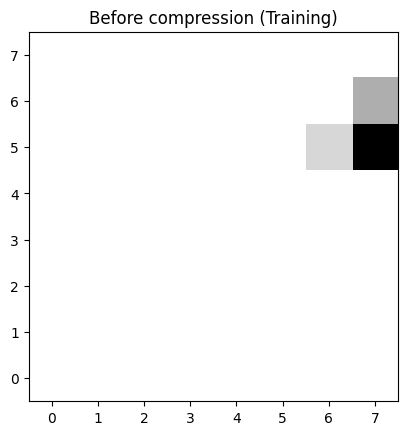

After


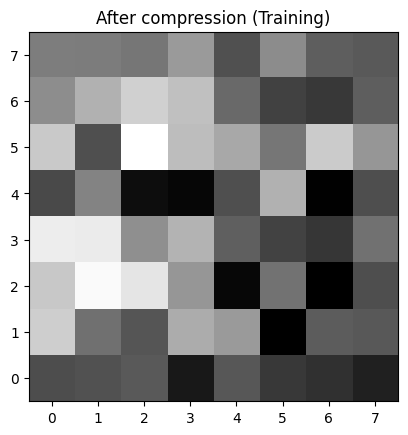

Epoch: 2 Avg train loss: 0.03399 Avg perplexity: 1.8239623308181763
Epoch: 3 Avg train loss: 0.03360 Avg perplexity: 2.9310684204101562
Epoch: 4 Avg train loss: 0.03329 Avg perplexity: 4.423107147216797
Epoch: 5 Avg train loss: 0.03086 Avg perplexity: 14.624739646911621
Epoch: 6 Avg train loss: 0.02774 Avg perplexity: 31.4736385345459
Epoch: 7 Avg train loss: 0.02394 Avg perplexity: 48.300743103027344
Epoch: 8 Avg train loss: 0.02061 Avg perplexity: 62.77705001831055
Epoch: 9 Avg train loss: 0.01792 Avg perplexity: 71.45455169677734
Epoch: 10 Avg train loss: 0.01614 Avg perplexity: 71.84961700439453
Latent vector encoder output size: torch.Size([2, 2])
Codebook size: num_embeddings=128, latent_dim=16
Before:


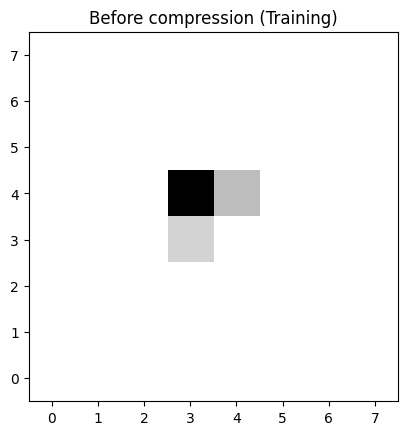

After


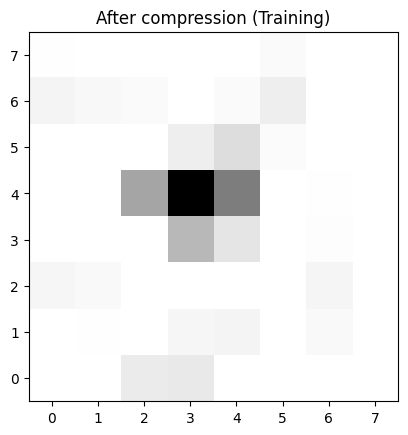

Epoch: 11 Avg train loss: 0.01498 Avg perplexity: 72.69654083251953
Epoch: 12 Avg train loss: 0.01384 Avg perplexity: 72.06446075439453
Epoch: 13 Avg train loss: 0.01300 Avg perplexity: 72.2366943359375
Epoch: 14 Avg train loss: 0.01210 Avg perplexity: 72.04358673095703
Epoch: 15 Avg train loss: 0.01151 Avg perplexity: 72.35323333740234
Epoch: 16 Avg train loss: 0.01082 Avg perplexity: 72.66477966308594
Epoch: 17 Avg train loss: 0.01047 Avg perplexity: 71.6304931640625
Epoch: 18 Avg train loss: 0.00981 Avg perplexity: 70.7789306640625
Epoch: 19 Avg train loss: 0.00956 Avg perplexity: 70.1139907836914
Epoch: 20 Avg train loss: 0.00919 Avg perplexity: 70.76573944091797
Latent vector encoder output size: torch.Size([2, 2])
Codebook size: num_embeddings=128, latent_dim=16
Before:


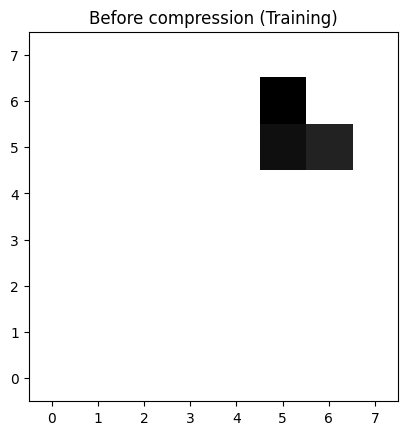

After


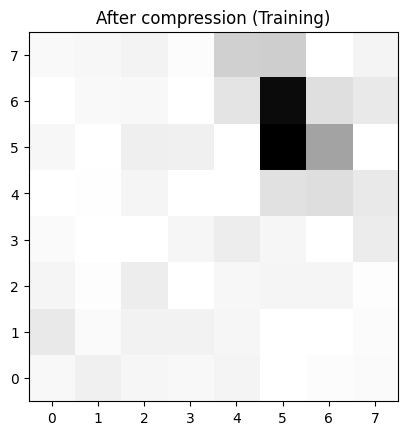

Epoch: 21 Avg train loss: 0.00880 Avg perplexity: 71.45097351074219
Epoch: 22 Avg train loss: 0.00861 Avg perplexity: 71.502685546875
Epoch: 23 Avg train loss: 0.00814 Avg perplexity: 73.1718978881836
Epoch: 24 Avg train loss: 0.00793 Avg perplexity: 73.50397491455078
Epoch: 25 Avg train loss: 0.00774 Avg perplexity: 72.30400085449219
Epoch: 26 Avg train loss: 0.00757 Avg perplexity: 72.48345184326172
Epoch: 27 Avg train loss: 0.00737 Avg perplexity: 72.76592254638672
Epoch: 28 Avg train loss: 0.00718 Avg perplexity: 72.94640350341797
Epoch: 29 Avg train loss: 0.00690 Avg perplexity: 73.14952850341797
Epoch: 30 Avg train loss: 0.00672 Avg perplexity: 72.81620788574219
Latent vector encoder output size: torch.Size([2, 2])
Codebook size: num_embeddings=128, latent_dim=16
Before:


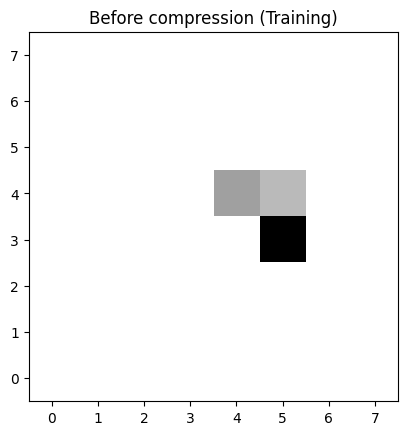

After


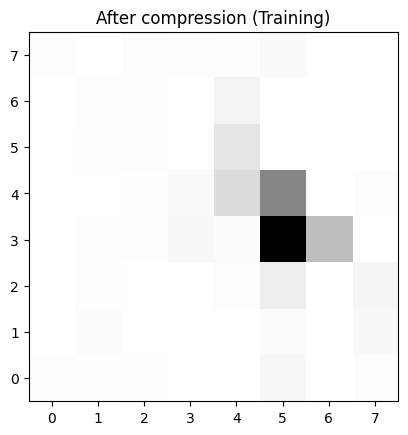

Epoch: 31 Avg train loss: 0.00661 Avg perplexity: 72.87283325195312
Epoch: 32 Avg train loss: 0.00646 Avg perplexity: 72.69795989990234
Epoch: 33 Avg train loss: 0.00646 Avg perplexity: 72.50035095214844
Epoch: 34 Avg train loss: 0.00629 Avg perplexity: 72.70462799072266
Epoch: 35 Avg train loss: 0.00630 Avg perplexity: 72.70526123046875
Epoch: 36 Avg train loss: 0.00612 Avg perplexity: 72.3150405883789
Epoch: 37 Avg train loss: 0.00598 Avg perplexity: 72.09025573730469
Epoch: 38 Avg train loss: 0.00585 Avg perplexity: 72.33322143554688
Epoch: 39 Avg train loss: 0.00574 Avg perplexity: 71.70978546142578
Epoch: 40 Avg train loss: 0.00573 Avg perplexity: 71.89329528808594
Latent vector encoder output size: torch.Size([2, 2])
Codebook size: num_embeddings=128, latent_dim=16
Before:


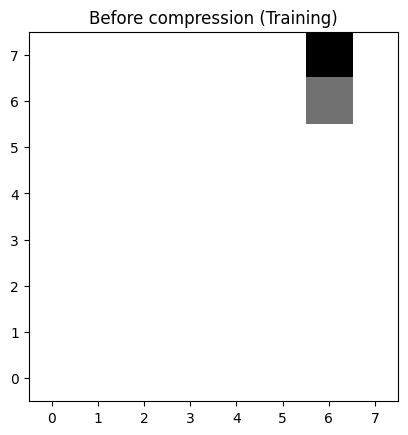

After


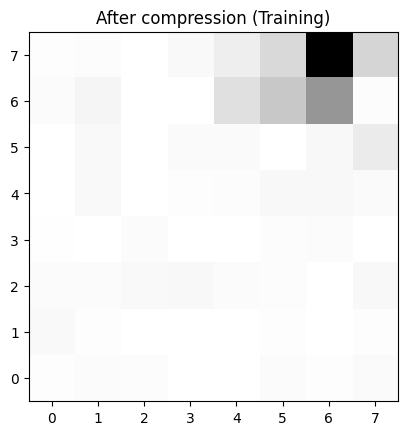

Epoch: 41 Avg train loss: 0.00574 Avg perplexity: 72.54370880126953
Epoch: 42 Avg train loss: 0.00564 Avg perplexity: 72.85943603515625
Epoch: 43 Avg train loss: 0.00560 Avg perplexity: 72.43883514404297
Epoch: 44 Avg train loss: 0.00541 Avg perplexity: 71.9714584350586
Epoch: 45 Avg train loss: 0.00527 Avg perplexity: 72.60350799560547
Epoch: 46 Avg train loss: 0.00526 Avg perplexity: 72.23969268798828
Epoch: 47 Avg train loss: 0.00521 Avg perplexity: 72.56846618652344
Epoch: 48 Avg train loss: 0.00519 Avg perplexity: 72.08131408691406
Epoch: 49 Avg train loss: 0.00512 Avg perplexity: 72.5621566772461
Epoch: 50 Avg train loss: 0.00507 Avg perplexity: 72.41622161865234
Latent vector encoder output size: torch.Size([2, 2])
Codebook size: num_embeddings=128, latent_dim=16
Before:


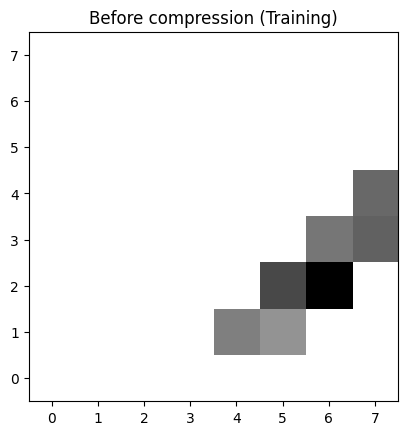

After


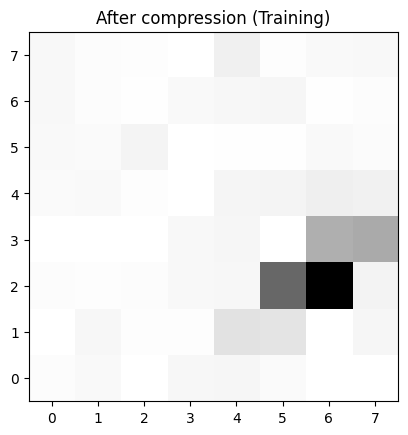

Epoch: 51 Avg train loss: 0.00497 Avg perplexity: 72.51390838623047
Epoch: 52 Avg train loss: 0.00491 Avg perplexity: 72.70777893066406
Epoch: 53 Avg train loss: 0.00493 Avg perplexity: 72.4329833984375
Epoch: 54 Avg train loss: 0.00487 Avg perplexity: 72.16663360595703
Epoch: 55 Avg train loss: 0.00491 Avg perplexity: 72.34833526611328
Epoch: 56 Avg train loss: 0.00484 Avg perplexity: 72.04203796386719
Epoch: 57 Avg train loss: 0.00476 Avg perplexity: 72.70874786376953
Epoch: 58 Avg train loss: 0.00471 Avg perplexity: 72.4675521850586
Epoch: 59 Avg train loss: 0.00467 Avg perplexity: 72.88892364501953
Epoch: 60 Avg train loss: 0.00466 Avg perplexity: 72.65681457519531
Latent vector encoder output size: torch.Size([2, 2])
Codebook size: num_embeddings=128, latent_dim=16
Before:


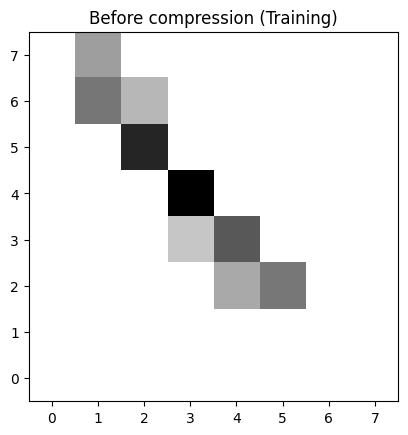

After


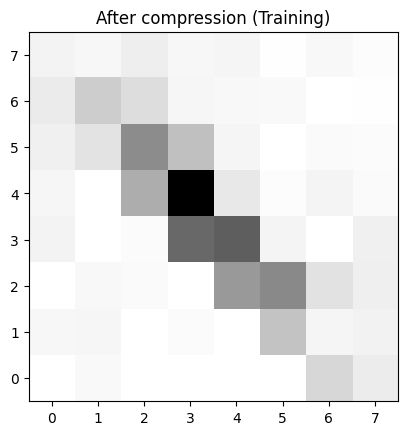

Epoch: 61 Avg train loss: 0.00462 Avg perplexity: 72.70771026611328
Epoch: 62 Avg train loss: 0.00455 Avg perplexity: 72.63674926757812
Epoch: 63 Avg train loss: 0.00443 Avg perplexity: 72.57470703125
Epoch: 64 Avg train loss: 0.00448 Avg perplexity: 72.29019927978516
Epoch: 65 Avg train loss: 0.00438 Avg perplexity: 71.99923706054688
Epoch: 66 Avg train loss: 0.00436 Avg perplexity: 71.94034576416016
Epoch: 67 Avg train loss: 0.00435 Avg perplexity: 71.72888946533203
Epoch: 68 Avg train loss: 0.00436 Avg perplexity: 72.30143737792969
Epoch: 69 Avg train loss: 0.00427 Avg perplexity: 71.77816772460938
Epoch: 70 Avg train loss: 0.00427 Avg perplexity: 72.6716079711914
Latent vector encoder output size: torch.Size([2, 2])
Codebook size: num_embeddings=128, latent_dim=16
Before:


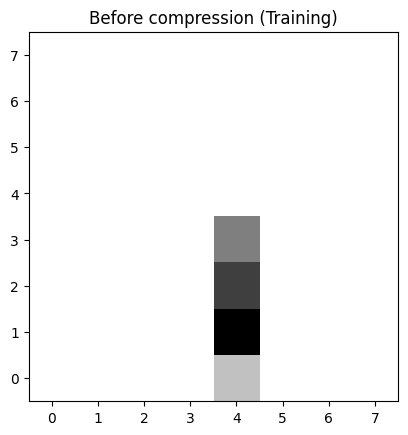

After


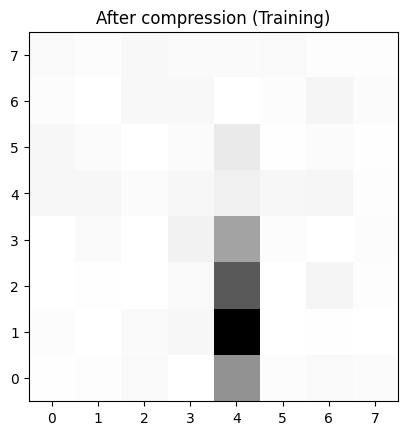

Epoch: 71 Avg train loss: 0.00420 Avg perplexity: 72.62667846679688
Epoch: 72 Avg train loss: 0.00419 Avg perplexity: 72.4964599609375
Epoch: 73 Avg train loss: 0.00417 Avg perplexity: 72.62362670898438
Epoch: 74 Avg train loss: 0.00420 Avg perplexity: 72.43131256103516
Epoch: 75 Avg train loss: 0.00409 Avg perplexity: 71.8641128540039
Epoch: 76 Avg train loss: 0.00407 Avg perplexity: 71.85198211669922
Epoch: 77 Avg train loss: 0.00407 Avg perplexity: 72.60945129394531
Epoch: 78 Avg train loss: 0.00399 Avg perplexity: 72.6468505859375
Epoch: 79 Avg train loss: 0.00399 Avg perplexity: 72.49117279052734
Epoch: 80 Avg train loss: 0.00402 Avg perplexity: 72.08318328857422
Latent vector encoder output size: torch.Size([2, 2])
Codebook size: num_embeddings=128, latent_dim=16
Before:


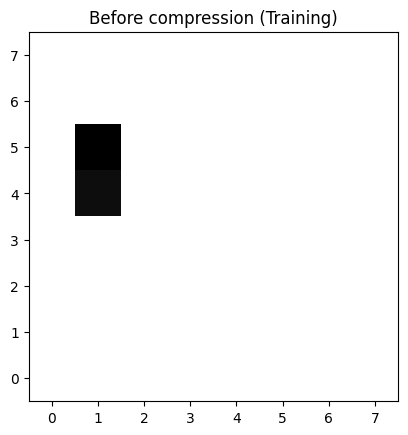

After


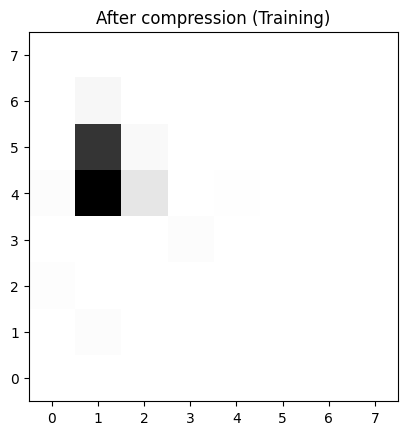

original data shape: torch.Size([64, 1, 8, 8])
encoded data shape: torch.Size([64, 16, 2, 2])
recon data shape: torch.Size([64, 1, 8, 8])
Before:


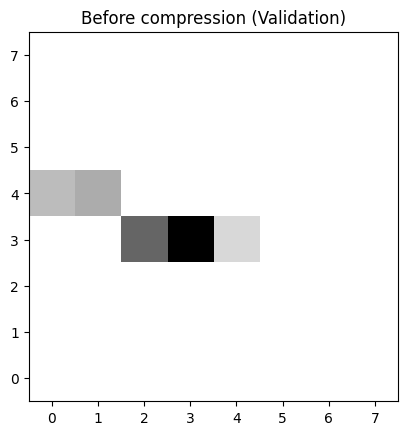

After
CPU times: user 37 s, sys: 66 ms, total: 37.1 s
Wall time: 37.1 s


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [ ]:
%%time
# Initialize dict to store results
results = {
    'n_updates': 0,
    'train_recon_errors': [], # start of train results
    'train_perplexities': [],
    'train_losses': [],
    'avg_train_loss_epochs': [],
    # 'test_recon_errors': [], # start of test results
    # 'test_perplexities': [],
    'test_losses': [],
    'avg_test_loss_epochs': [],
}

iters_train = len(train_loader)
iters_test = len(val_loader)

# TODO: generate_images functionality, save avg epoch and per iterations results, implement testing loop

for epoch in range(config["n_epochs"] + 1):
    # Training
    if epoch > 0:  # test untrained net first
        # Set model to training mode
        model.train()
        train_loss = 0.
        for (plot_idx, x) in enumerate(train_loader): # iters_train
            
            x = x.to(device)
            
            # ===================forward=====================
            embedding_loss, x_hat, perplexity, z_e, codebook, _ = model(x)
            
            recon_loss = torch.mean((x_hat - x)**2) #/ train_data_vars
            loss = recon_loss + embedding_loss
            train_loss += loss #.item()

            # ===================backward====================
            # zero out the previous gradients to prevent accumulation
            optimizer.zero_grad()
            # backpropagate
            loss.backward()
            optimizer.step()
            # scheduler.step(epoch + i / iters_train)

            results["train_recon_errors"].append(recon_loss.cpu().detach().numpy())
            results["train_perplexities"].append(perplexity.cpu().detach().numpy())
            results["train_losses"].append(loss.cpu().detach().numpy())

        results["n_updates"] += iters_train
        avg_train_loss = train_loss / iters_train # len(train_loader.dataset)
        avg_perplexity = np.mean(results["train_perplexities"][-iters_train:])
        results["avg_train_loss_epochs"].append(avg_train_loss)
        print(f'Epoch: {epoch} Avg train loss: {avg_train_loss:.5f} Avg perplexity: {avg_perplexity}')

        # display images (include plot after first training epoch, epoch 1)
        if epoch == 1 or epoch % config["plot_epochs"] == 0:
            print(f"Latent vector encoder output size: {z_e[0][0].shape}")
            
            num_embeddings, latent_dim = codebook.shape
            print(f"Codebook size: num_embeddings={num_embeddings}, latent_dim={latent_dim}")
            
            print("Before:")
            x_np = model_tool._tensor_to_numpy(x[0][0])
            encodings_np = model_tool._tensor_to_numpy(codebook)
            
            cms_plots.plot_patch(
                x_np, 
                "Before compression (Training)" 
            )
            patches_before_train.append(x_np)
            
            patches_encodings_train.append(encodings_np)
            
            print("After")
            x_hat_np = model_tool._tensor_to_numpy(x_hat[0][0])
            x_hat_np_clipped = np.clip(x_hat_np, -1, 1)
            
            cms_plots.plot_patch(
                x_hat_np_clipped,
                "After compression (Training)" 
            )            
            patches_after_train.append(x_hat_np_clipped)
            
            # display_image_grid_side_by_side(x, x_hat, codebook, epoch=epoch)
            plt.show()

    if epoch == config["n_epochs"]:
        # Testing (Validation)
        with torch.no_grad():
            model.eval()
            test_loss = 0.
            # image, label
            for x_test in val_loader:
                x_test = x_test.to(device)
                # ===================forward=====================
                embedding_loss, x_hat_test, perplexity, z_e, codebook, z_q = model(x_test, verbose=True)
                recon_loss = torch.mean((x_hat_test - x_test)**2) #/ train_data_vars # NOTE: this is pretty interesting, not standard afaik
                loss = recon_loss + embedding_loss
                test_loss += loss #.item()
                
                print("Before:")
                x_np = model_tool._tensor_to_numpy(x_test[0][0])
                cms_plots.plot_patch(
                    x_np, 
                    "Before compression (Validation)" 
                )
                patches_before_val.append(x_np)
                
                encodings_np = model_tool._tensor_to_numpy(codebook)
                patches_encodings_val.append(encodings_np)
                
                print("After")
                x_hat_np = model_tool._tensor_to_numpy(x_hat_test[0][0])
                x_hat_clipped = np.clip(x_hat_np, -1, 1)
                patches_after_val.append(x_hat_clipped)
                
                cms_plots.plot_patch(
                    x_hat_clipped,
                    "After compression (Validation)" 
                )
                
                # results["test_recon_errors"].append(recon_loss.cpu().detach().numpy())
                # results["test_perplexities"].append(perplexity.cpu().detach().numpy())
                results["test_losses"].append(loss.cpu().detach().numpy())
                
                # compression ratio
                width_val, height_val = z_q[0][0].shape
                c_width, c_height = codebook.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------------------------------")
                print(
                    f"Patch encoder output dimensions:"
                    f"(w x h) = ({width_val}) x ({height_val})"
                )
                
                compression_ratio = cms_data_tool._get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(width_val, height_val, config["n_embeddings"]),
                    patch_size=PATCH_SIZE
                )
                total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
                    (
                        width_val, 
                        height_val, 
                        config["n_embeddings"]
                    ), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {config["n_embeddings"]}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
                
                

        avg_test_loss = test_loss / iters_test # len(val_loader.dataset)
        results["avg_test_loss_epochs"].append(avg_test_loss)
        print(f'Average test loss: {avg_test_loss:.5f}')

# save model and results
save_model_and_results(model, results)

In [ ]:
def load_model(checkpoint_path):
    if torch.cuda.is_available():
        checkpoint = torch.load(checkpoint_path)
    else: # CPU
        checkpoint = torch.load(checkpoint_path, map_location=lambda storage, loc: storage)

    results = checkpoint["results"]
    config = checkpoint["config"]

    model = VQVAE(config['n_hiddens'], config['n_residual_hiddens'],
                  config['n_residual_layers'], config['n_embeddings'],
                  config['embedding_dim'], config['beta']).to(device)

    model.load_state_dict(checkpoint['model'])

    return model, config, results


def plot_metrics(results):
    recon_errors = savgol_filter(results["train_recon_errors"], 19, 5)
    perplexities = savgol_filter(results["train_perplexities"], 19, 5)
    loss_vals = savgol_filter(results["train_losses"], 19, 5)


    f = plt.figure(figsize=(16,4))
    ax = f.add_subplot(1,3,2)
    ax.plot(recon_errors)
    ax.set_yscale('log')
    ax.set_title('Reconstruction Error')
    ax.set_xlabel('iteration')

    ax = f.add_subplot(1,3,3)
    ax.plot(perplexities)
    ax.set_title('Average codebook usage (perplexity).')
    ax.set_xlabel('iteration')

    ax = f.add_subplot(1,3,1)
    ax.plot(loss_vals)
    ax.set_yscale('log')
    ax.set_title('Overall Loss')
    ax.set_xlabel('iteration')

def reconstruct(data_loader, model):
    (x, _) = next(iter(data_loader))
    x = x.to(device)
    vq_encoder_output = model.pre_quantization_conv(model.encoder(x))
    _, z_q, _, _,e_indices = model.vector_quantization(vq_encoder_output)

    x_recon = model.decoder(z_q)
    return x,x_recon, z_q, e_indices

In [ ]:
patches_before_train[0].shape

(8, 8)

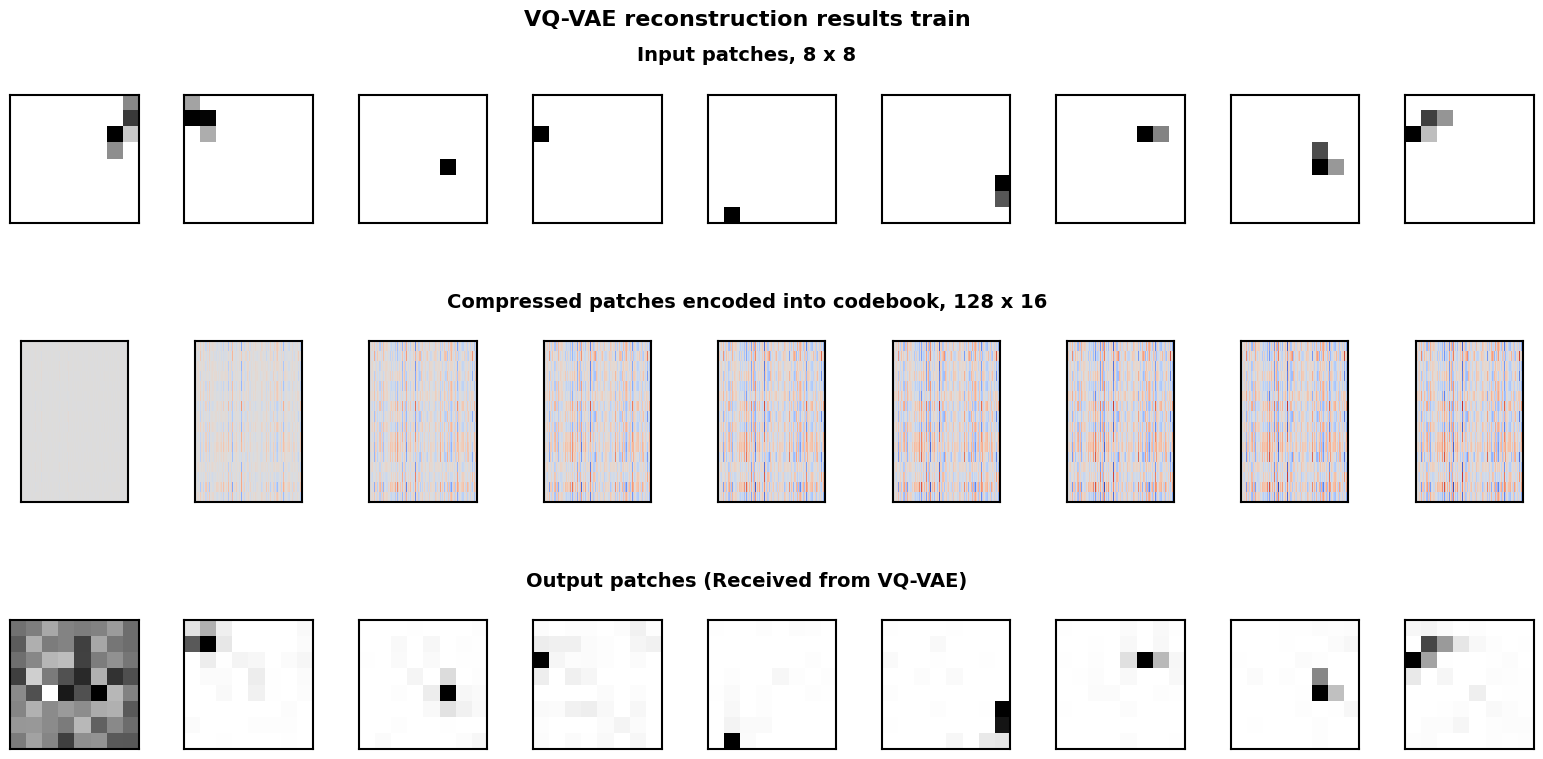

In [ ]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, "
        f"{config["n_embeddings"]} x {config["embedding_dim"]}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train")

In [ ]:
# patches_encodings_train

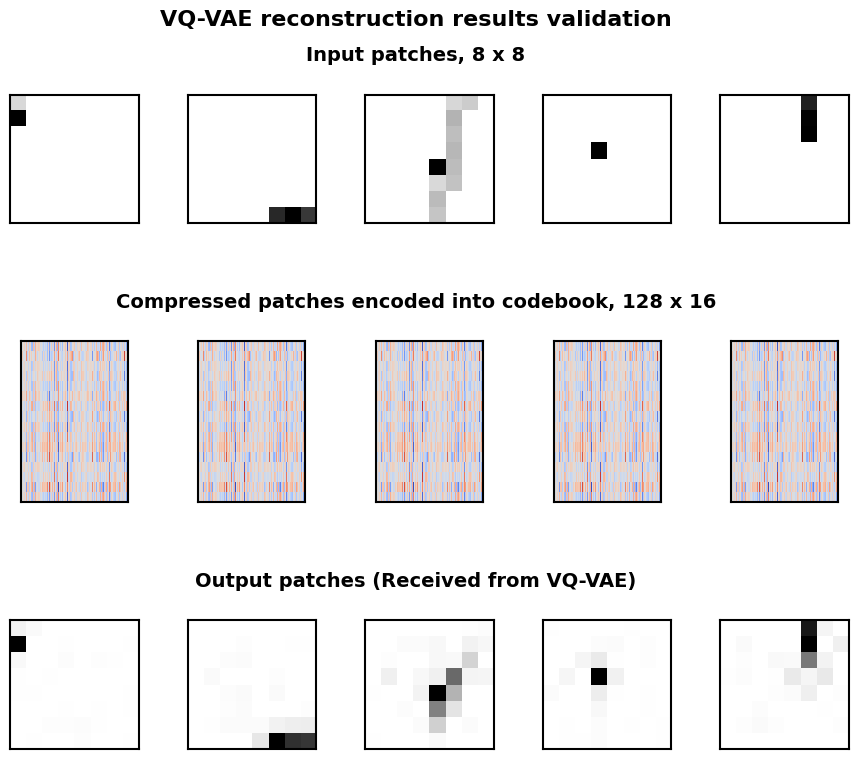

In [ ]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (
        patches_encodings_val, 
        f"Compressed patches encoded into codebook, "
        f"{config["n_embeddings"]} x {config["embedding_dim"]}"
    ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results validation")

In [ ]:
# patches_encodings_val

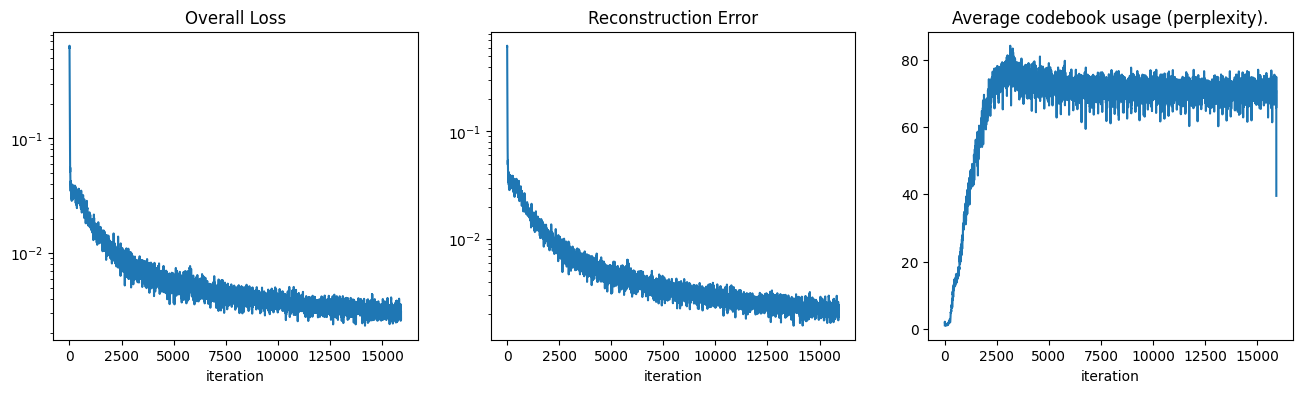

In [ ]:
plot_metrics(results)